
# Módulo 7 – Model Tuning e Hyperparameter Optimization (HPO)
**Notebook prático** – exemplos com scikit-learn + explicações em Markdown  
Autor: *Thiago Azeredo* (coordenação)  

> Este notebook demonstra na prática: baseline, `GridSearchCV`, `RandomizedSearchCV`, *Successive Halving* (`HalvingGridSearchCV`) e *tuning com Pipeline*.
> Também inclui seções em texto sobre Otimização Bayesiana (Optuna/Hyperopt), Deep Learning (DL) e LLMs/RAG, para você adaptar quando tiver esses pacotes no ambiente.



## 0. Ambiente e reprodutibilidade
- Usaremos apenas **scikit-learn** (já comum na maioria dos ambientes).
- Fixamos `random_state` para reprodutibilidade.
- Métrica principal: `f1` (para classificação desbalanceada) e `accuracy` como referência.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform


# Explicação do Código – HalvingGridSearchCV (scikit-learn)

Este trecho de código prepara o ambiente para utilizar o **HalvingGridSearchCV**, 
uma técnica de **otimização de hiperparâmetros** baseada em *Successive Halving*.

---

## 1. Bloco `try/except`

```python
try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingGridSearchCV
    HALVING_AVAILABLE = True
except Exception:
    HALVING_AVAILABLE = False
```

- O `HalvingGridSearchCV` ainda está na API **experimental** do scikit-learn.  
- Para habilitá-lo, é necessário importar antes:

  ```python
  from sklearn.experimental import enable_halving_search_cv
  ```

  Esse import não é usado diretamente (por isso o comentário `# noqa: F401`, que evita warnings), 
  mas **ativa** a funcionalidade experimental.  

- Em seguida, importa-se o `HalvingGridSearchCV`.  
- Se a versão instalada do scikit-learn não tiver suporte, o código cai no `except` 
  e a flag `HALVING_AVAILABLE` será `False`.

---

## 2. Semente de aleatoriedade

```python
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
```

- Define um valor fixo para a semente aleatória, garantindo **reprodutibilidade** dos experimentos.  
- O número `42` é apenas uma convenção popular, mas poderia ser qualquer inteiro.

---

## 3. Impressão das versões

```python
print("Versões:")
import sklearn, scipy
print("  scikit-learn:", sklearn.__version__)
```

- Exibe a versão do `scikit-learn` instalada no ambiente.  
- Importante porque o `HalvingGridSearchCV` só está disponível a partir da versão **0.24**.  
- Também importa `scipy`, pois vários algoritmos do scikit-learn dependem dessa biblioteca.

---

## ✅ Resumindo

Esse código tem três finalidades principais:

1. **Verificar** se o `HalvingGridSearchCV` está disponível na instalação atual.  
2. **Definir reprodutibilidade** ao fixar a semente de geração aleatória.  
3. **Exibir as versões** do scikit-learn (e implicitamente do SciPy) para debug.

---

## 🔍 Observação

O `HalvingGridSearchCV` é uma versão mais eficiente do `GridSearchCV`, pois:
- Testa muitas combinações de hiperparâmetros com **menos recursos**.
- Vai **eliminando** os piores candidatos a cada iteração.
- Concentra mais recursos nas melhores combinações.

---

In [ ]:
# Halving (Successive Halving) - pode requerer habilitar experimental
try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingGridSearchCV
    HALVING_AVAILABLE = True
except Exception:
    HALVING_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versões:")
import sklearn, scipy
print("  scikit-learn:", sklearn.__version__)
print("  scipy:", scipy.__version__)
print("HalvingGridSearchCV disponível?", HALVING_AVAILABLE)



## 1. Carregando dados e criando *baseline*
Utilizaremos o conjunto **Breast Cancer Wisconsin** (classificação binária).  
Separaremos treino/teste e treinaremos um baseline simples com `RandomForestClassifier`.


In [ ]:

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

baseline = RandomForestClassifier(random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline, X_train, y_train, cv=5, scoring="f1")
print(f"Baseline CV F1 (RF, default): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
print("Baseline Teste -> Accuracy:", accuracy_score(y_test, y_pred))
print("Baseline Teste -> F1:", f1_score(y_test, y_pred))
print("\nRelatório de Classificação (baseline):\n", classification_report(y_test, y_pred))



## 2. Grid Search (`GridSearchCV`)
Exploramos sistematicamente combinações de hiperparâmetros de uma **Random Forest**.
> Vantagem: cobertura completa do grid.  
> Desvantagem: explode combinatorialmente com muitos hiperparâmetros/valores.


In [11]:

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"]
}
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Melhor combinação (Grid):", grid.best_params_)
print(f"Melhor CV F1 (Grid): {grid.best_score_:.4f}")

best_grid = grid.best_estimator_
y_pred_grid = best_grid.predict(X_test)
print("Teste (Grid) -> Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Teste (Grid) -> F1:", f1_score(y_test, y_pred_grid))


Melhor combinação (Grid): {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Melhor CV F1 (Grid): 0.9668
Teste (Grid) -> Accuracy: 0.9473684210526315
Teste (Grid) -> F1: 0.9583333333333334



## 3. Random Search (`RandomizedSearchCV`)
Amostra aleatoriamente configurações dentro de intervalos/probabilidades.
> Vantagem: cobre melhor espaços grandes sob orçamento fixo.  
> Desvantagem: não garante ótimo global, mas costuma encontrar bons valores rapidamente.


In [12]:

param_dist = {
    "n_estimators": randint(100, 800),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None]
}

rnd = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rnd.fit(X_train, y_train)

print("Melhores hiperparâmetros (Random):", rnd.best_params_)
print(f"Melhor CV F1 (Random): {rnd.best_score_:.4f}")

best_rnd = rnd.best_estimator_
y_pred_rnd = best_rnd.predict(X_test)
print("Teste (Random) -> Accuracy:", accuracy_score(y_test, y_pred_rnd))
print("Teste (Random) -> F1:", f1_score(y_test, y_pred_rnd))


Melhores hiperparâmetros (Random): {'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 741}
Melhor CV F1 (Random): 0.9684
Teste (Random) -> Accuracy: 0.956140350877193
Teste (Random) -> F1: 0.9655172413793104



## 4. *Successive Halving* (`HalvingGridSearchCV`)
Método multi-fidelidade: começa com muitas configurações baratas (menos recursos) e, a cada rodada, **elimina** as piores, alocando mais recursos para as melhores.

> Observação: Requer `from sklearn.experimental import enable_halving_search_cv` (habilitado no início). Se não estiver disponível, esta célula apenas informará.


In [13]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_halving = {
    # REMOVA n_estimators do grid:
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
}

halving = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_halving,
    scoring="f1",
    cv=5,
    factor=2,
    resource="n_estimators",  # recurso varia por rodada
    min_resources=100,        # inteiros coerentes com seu orçamento
    max_resources=900,
    n_jobs=-1,
    verbose=1,
)

halving.fit(X_train, y_train)


n_iterations: 4
n_required_iterations: 5
n_possible_iterations: 4
min_resources_: 100
max_resources_: 900
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 24
n_resources: 100
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 12
n_resources: 200
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 2
n_candidates: 6
n_resources: 400
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 3
n_resources: 800
Fitting 5 folds for each of 3 candidates, totalling 15 fits


HalvingGridSearchCV(estimator=RandomForestClassifier(random_state=42), factor=2,
                    max_resources=900, min_resources=100, n_jobs=-1,
                    param_grid={'max_depth': [None, 5, 10, 20],
                                'max_features': ['sqrt', 'log2'],
                                'min_samples_split': [2, 5, 10]},
                    resource='n_estimators', scoring='f1', verbose=1)


## 5. Tuning com `Pipeline`: *SVC* + *StandardScaler*
Em muitos casos, o melhor desempenho vem de **pipelines** que incluem pré-processamento.  
Aqui ajustamos hiperparâmetros de um `SVC` juntamente com o `StandardScaler`.


In [14]:

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "tocsc") else StandardScaler()),
    ("svc", SVC(random_state=RANDOM_STATE))
])

param_grid_svc = {
    "svc__kernel": ["rbf", "linear"],
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.1, 0.01, 0.001]
}

grid_svc = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_svc,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid_svc.fit(X_train, y_train)

print("Melhor combinação (Pipeline SVC):", grid_svc.best_params_)
print(f"Melhor CV F1 (Pipeline SVC): {grid_svc.best_score_:.4f}")

best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test)
print("Teste (Pipeline SVC) -> Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Teste (Pipeline SVC) -> F1:", f1_score(y_test, y_pred_svc))


Melhor combinação (Pipeline SVC): {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Melhor CV F1 (Pipeline SVC): 0.9844
Teste (Pipeline SVC) -> Accuracy: 0.9824561403508771
Teste (Pipeline SVC) -> F1: 0.9861111111111112



## 6. Comparação final e matriz de confusão
Escolha o melhor modelo do seu experimento e avalie no conjunto de teste.  
Aqui, comparamos rapidamente as variantes treinadas.


         Modelo  F1 (teste)
4  Pipeline SVC    0.986111
0   Baseline RF    0.965517
2     Random RF    0.965517
3    Halving RF    0.965517
1       Grid RF    0.958333


<Figure size 640x480 with 0 Axes>

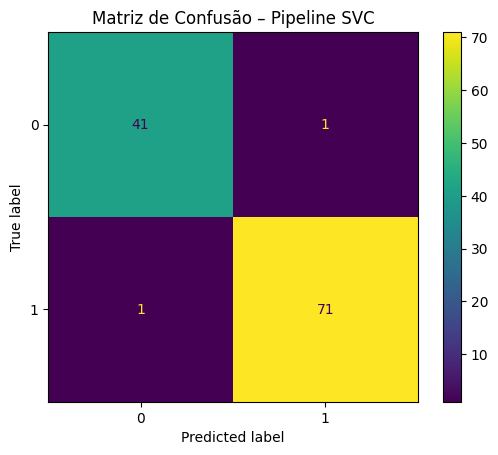

In [15]:

import matplotlib.pyplot as plt

results = []

# Baseline
y_pred = baseline.predict(X_test)
results.append(("Baseline RF", f1_score(y_test, y_pred)))

# Grid RF
y_pred_grid = grid.best_estimator_.predict(X_test)
results.append(("Grid RF", f1_score(y_test, y_pred_grid)))

# Random RF
y_pred_rnd = rnd.best_estimator_.predict(X_test)
results.append(("Random RF", f1_score(y_test, y_pred_rnd)))

# Halving RF (se houver)
if HALVING_AVAILABLE:
    y_pred_halving = halving.best_estimator_.predict(X_test)
    results.append(("Halving RF", f1_score(y_test, y_pred_halving)))

# Pipeline SVC
y_pred_svc = best_svc.predict(X_test)
results.append(("Pipeline SVC", f1_score(y_test, y_pred_svc)))

df_results = pd.DataFrame(results, columns=["Modelo", "F1 (teste)"]).sort_values("F1 (teste)", ascending=False)
print(df_results)

# Matriz de confusão do melhor
best_name, _ = df_results.iloc[0]
if best_name == "Baseline RF":
    best_model = baseline
elif best_name == "Grid RF":
    best_model = grid.best_estimator_
elif best_name == "Random RF":
    best_model = rnd.best_estimator_
elif best_name == "Halving RF" and HALVING_AVAILABLE:
    best_model = halving.best_estimator_
else:
    best_model = best_svc

fig = plt.figure()  # regra: um gráfico por figura, sem cores específicas
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Matriz de Confusão – {best_name}")
plt.show()
